<a href="https://colab.research.google.com/github/JeongDell/Like-Lion-NLP-4th/blob/main/MovieReview_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLTK 불러오기

In [1]:
import nltk
from sklearn.model_selection import train_test_split

# NLTK 예제 데이터셋(movie_reviews) 다운로드
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews

# 데이터 준비 (문서와 해당 카테고리)
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# 데이터를 Train과 Test로 9:1 비율로 분리
train_data, test_data = train_test_split(documents, test_size=0.1, random_state=42)

print(f"전체 데이터 수: {len(documents)}")
print(f"Train 데이터 수: {len(train_data)}")
print(f"Test 데이터 수: {len(test_data)}")


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


전체 데이터 수: 2000
Train 데이터 수: 1800
Test 데이터 수: 200


In [2]:
import pandas as pd
from google.colab import files

# 준비된 documents 데이터를 DataFrame으로 변환
df = pd.DataFrame([(' '.join(words), category) for words, category in documents], columns=['review', 'sentiment'])

# CSV 파일로 저장
file_name = 'movie_reviews.csv'
df.to_csv(file_name, index=False, encoding='utf-8')

# 로컬 PC로 다운로드
files.download(file_name)
print(f"{file_name} 파일 다운로드를 시작합니다.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

movie_reviews.csv 파일 다운로드를 시작합니다.


In [3]:
import pandas as pd

# Sentence Piece 단어사전 만들기

In [4]:
!pip install -q sentencepiece
import sentencepiece as spm

In [5]:
with open('spm_train_data.txt', 'w', encoding='utf-8') as f:
    # train_data는 (단어 리스트, 카테고리) 튜플입니다.
    for words, category in train_data:
        # 단어 리스트를 하나의 문자열로 결합합니다.
        text = ' '.join(words)
        f.write(text + '\n')

print("SentencePiece 학습용 텍스트 파일(spm_train_data.txt) 생성 완료!")


SentencePiece 학습용 텍스트 파일(spm_train_data.txt) 생성 완료!


In [6]:
# 2. SentencePiece 모델 학습
print("SentencePiece 학습 시작...")
spm.SentencePieceTrainer.train(
    input='spm_train_data.txt',
    # 저장될 모델 파일 이름
    model_prefix='spm_bpe',

    # 적절한 vocab_size 설정 팁:
    # 1. 데이터셋 크기에 비례 (소규모: 4k~8k, 대규모: 32k~65k)
    # 2. 다운스트림 태스크(분류 등)의 검증 성능이 가장 높은 값으로 튜닝
    # 3. 토큰 시퀀스 길이와 희귀 토큰 수 사이의 균형점을 찾음
    # 일단 8000으로 시행
    vocab_size=8000,

    # 토큰 분리 방식
    model_type='bpe', # BPE 방식 사용 (unigram도 가능)
    # 패딩 토큰 ID 설정
    pad_id=0,
    # Out of Vocabulary 특수 토큰 ID 설정
    unk_id=1,
    # 문장 시작 ID 토큰
    bos_id=2,
    # 문장 끝 ID 토큰
    eos_id=3
)
print("학습 완료! 'spm_bpe.model'과 'spm_bpe.vocab' 파일이 생성되었습니다.")


SentencePiece 학습 시작...
학습 완료! 'spm_bpe.model'과 'spm_bpe.vocab' 파일이 생성되었습니다.


In [7]:
# 1. 학습된 SentencePiece 모델 로드
sp = spm.SentencePieceProcessor()
sp.load('spm_bpe.model')

# 2. 샘플 텍스트 토큰화 테스트 (첫 번째 Train 데이터)
sample_text = ' '.join(train_data[0][0])
print("=== 원본 텍스트 ===")
print(f"{sample_text[:150]}...\n")

# 3. 텍스트를 Subword 토큰(Pieces)으로 변환
tokens = sp.encode_as_pieces(sample_text)
print("=== 토큰화 결과 (Pieces) ===")
print(f"{tokens[:20]}...\n")

# 4. 텍스트를 정수 인덱스(IDs)로 변환
token_ids = sp.encode_as_ids(sample_text)
print("=== 정수 인코딩 결과 (IDs) ===")
print(f"{token_ids[:20]}...")


=== 원본 텍스트 ===
robert redford is very good at playing characters who have incredible , god - given gifts , but are able to act like ordinary people . in " the natura...

=== 토큰화 결과 (Pieces) ===
['▁robert', '▁redford', '▁is', '▁very', '▁good', '▁at', '▁playing', '▁characters', '▁who', '▁have', '▁incredible', '▁,', '▁god', '▁-', '▁given', '▁gift', 's', '▁,', '▁but', '▁are']...

=== 정수 인코딩 결과 (IDs) ===
[1247, 6051, 45, 348, 293, 132, 1253, 384, 137, 180, 3805, 11, 1224, 63, 1089, 4497, 7957, 11, 112, 124]...


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split

# 3. 학습 데이터를 Train 데이터와 Validation 데이터로 8:2로 분리
train_split, val_split = train_test_split(train_data, test_size=0.2, random_state=42)
print(f"Train 데이터 수: {len(train_split)}, Validation 데이터 수: {len(val_split)}")

# 감성 라벨을 정수로 변환하기 위한 딕셔너리 ('pos' -> 1, 'neg' -> 0)
label_dict = {'pos': 1, 'neg': 0}




Train 데이터 수: 1440, Validation 데이터 수: 360


Train 데이터 중 가장 긴 리뷰의 토큰 수: 3562
Train 데이터 평균 리뷰의 토큰 수: 907.3155555555555
Train 데이터 리뷰 토큰 수의 최빈값: 767


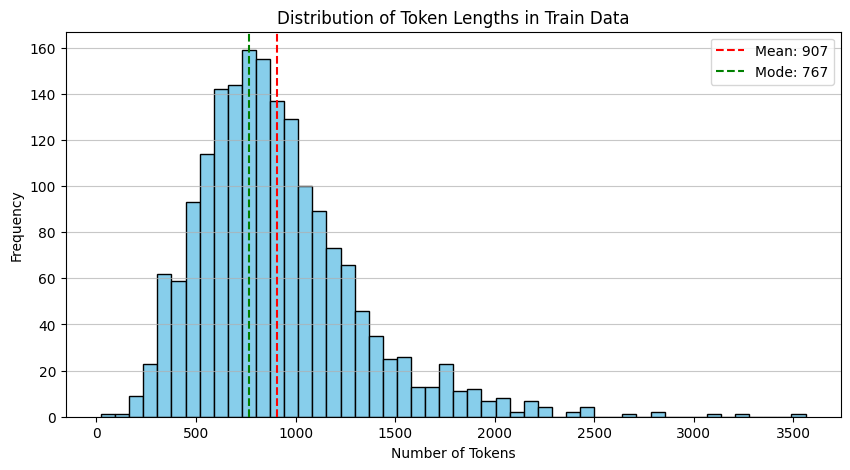

In [9]:
from numpy import mean
from statistics import mode
import matplotlib.pyplot as plt

# 효율성을 위해 토큰 길이를 한 번만 계산하여 리스트로 저장
token_lengths = [len(sp.encode_as_ids(' '.join(words))) for words, category in train_data]

# 최대, 평균, 최빈값 계산
max_token_length = max(token_lengths)
mean_token_length = mean(token_lengths)
mode_token_length = mode(token_lengths)

print(f"Train 데이터 중 가장 긴 리뷰의 토큰 수: {max_token_length}")
print(f"Train 데이터 평균 리뷰의 토큰 수: {mean_token_length}")
print(f"Train 데이터 리뷰 토큰 수의 최빈값: {mode_token_length}")

# 토큰 수 분포 그래프 그리기
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(mean_token_length, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_token_length:.0f}')
plt.axvline(mode_token_length, color='green', linestyle='dashed', linewidth=1.5, label=f'Mode: {mode_token_length}')
plt.title('Distribution of Token Lengths in Train Data')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()


In [10]:
# 4 & 5. PyTorch Dataset 클래스 정의 (토큰화 및 텐서 변환 포함)
class MovieReviewDataset(Dataset):
  #토큰 수 768개로 제한
    def __init__(self, data, sp_model, max_len=768):
        self.data = data
        self.sp = sp_model
        self.max_len = max_len # 문장의 최대 길이 제한

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        words, category = self.data[idx]
        text = ' '.join(words)

        # 4. 단어사전을 통해 텍스트를 토큰화 (정수 인덱스로 변환)
        token_ids = self.sp.encode_as_ids(text)

        # 설정한 최대 길이까지만 자르기
        token_ids = token_ids[:self.max_len]

        # 카테고리를 정수 라벨로 변환
        label = label_dict[category]

        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# 5. 각 데이터에 Padding을 추가하기 위한 collate_fn 함수 정의
def collate_fn(batch):
    # 배치 데이터를 시퀀스(텍스트)와 라벨로 분리
    sequences, labels = zip(*batch)

    # 패딩을 추가하여 배치 내 텐서들의 길이를 가장 긴 시퀀스 길이에 맞춤
    # SentencePiece 학습 시 설정한 pad_id=0을 padding_value로 사용
    # batch_first=True를 통해 (배치 크기, 시퀀스 길이) 형태의 텐서로 반환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)

    return padded_seqs, labels

# 데이터셋 객체 생성 (Train, Validation, Test)
train_dataset = MovieReviewDataset(train_split, sp)
val_dataset = MovieReviewDataset(val_split, sp)
test_dataset = MovieReviewDataset(test_data, sp) # 테스트 데이터 토큰화 적용

# 6. DataLoader 만들기 (배치 단위로 데이터를 불러오기 위해 사용)
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("DataLoader 생성 완료!")
print(f"Train 배치의 수: {len(train_loader)}")
print(f"Validation 배치의 수: {len(val_loader)}")
print(f"Test 배치의 수: {len(test_loader)}")

DataLoader 생성 완료!
Train 배치의 수: 45
Validation 배치의 수: 12
Test 배치의 수: 7


# RNN 활용 모델 설계


1.input
- ([토크화 거친 리뷰], POS/NEG 여부)인 튜플로 구성 됨

2.output
- NEG인지 POS인지 확률 추정 -> Cross Entropy loss function 사용할 필요 있음
- 0.5를 기준으로 하나의 결과를 출력하도록 설정
- 마지막에 전체 맥락으로 판단하기 때문에 RNN의 모든 OUPUT을 전달할 필요가 없음

3.중간 layer
- input 입력 받아서 임베당 차원에 올리기
  - 몇 차원에 올릴지, word2vec 같은 pre-trained를 쓸지 test 필요
- RNN Hidden Layer
  - 몇 차원으로 설장할지 test 필요

4. 전체 학습 과정
- optimizer는 무엇으로?


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# 하이퍼파라미터 설정
VOCAB_SIZE = 8000 # SentencePiece 모델 학습 시 설정한 단어사전 크기
EMBED_DIM = 128   # 임베딩 차원 수
HIDDEN_DIM = 256  # RNN 은닉층 차원 수
OUTPUT_DIM = 2    # pos, neg 각각의 확률(점수)을 구하기 위해 출력 차원을 2로 변경
DROPOUT_RATE = 0.5 # 드롭아웃 비율 설정

# RNN의 출력(output, hidden) 중 마지막 은닉 상태만 다음 레이어로 넘겨주는 헬퍼 클래스
class ExtractLastHidden(nn.Module):
  #output:모든 hidden state의 모음집,output: [hidden_1, hidden_2, hidden_3] (모든 중간 과정의 문맥들) , hidden: [hidden_3] (맨 마지막 문맥)
    def forward(self, x):
        output, hidden = x
        # hidden 형태: [num_layers, batch_size, hidden_dim]
        # squeeze(0)을 통해 [batch_size, hidden_dim]으로 변환하여 반환
        return hidden.squeeze(0)

# 1. nn.Sequential을 이용해 레이어를 순서대로 쌓아 올리는 방식
model = nn.Sequential(
    # (1) 임베딩 레이어
    nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0),

    # (2) 과적합 방지용 Dropout
    nn.Dropout(DROPOUT_RATE),

    # (3) RNN 레이어
    nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True),

    # (4) RNN 출력에서 마지막 은닉 상태만 추출
    ExtractLastHidden(),

    # (5) 분류기 전 추가 Dropout
    nn.Dropout(DROPOUT_RATE),

    # (6) 출력 레이어 (선형 분류기)
    # - HIDDEN_DIM (입력): 리뷰 전체를 다 읽고 요약한 256차원의 문맥 벡터 (최종 은닉 상태)
    # - OUTPUT_DIM (출력): [부정(0) 점수, 긍정(1) 점수] 2개의 최종 판별 점수
    nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
)

# 2. 손실 함수와 옵티마이저 정의
# 두 개 이상의 클래스 확률을 다룰 때는 CrossEntropyLoss를 사용합니다.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# GPU 사용 가능 여부 확인 및 모델 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = criterion.to(device)

print("Sequential 방식 모델 파이프라인 (Dropout 포함) 준비 완료! 현재 사용 기기:", device)
print(model)


Sequential 방식 모델 파이프라인 (Dropout 포함) 준비 완료! 현재 사용 기기: cuda
Sequential(
  (0): Embedding(8000, 128, padding_idx=0)
  (1): Dropout(p=0.5, inplace=False)
  (2): RNN(128, 256, batch_first=True)
  (3): ExtractLastHidden()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=256, out_features=2, bias=True)
)


In [12]:
import time
import numpy as np
from tqdm.auto import tqdm # 진행률과 남은 시간을 표시하기 위한 라이브러리 추가

EPOCHS = 20 # 전체 데이터를 몇 번 반복 학습할지 설정
PATIENCE = 5 # Early Stopping: 개선이 없을 때 기다려줄 에폭 수

best_val_loss = np.inf # 최고 검증 손실을 무한대로 초기화
patience_counter = 0 # 인내 카운터 초기화

print("모델 학습을 시작합니다...")
for epoch in range(EPOCHS):
    start_time = time.time()

    # ================================
    # 1. 학습 (Training) 단계
    # ================================
    model.train() # 모델을 학습 모드로 설정 (Dropout 활성화)
    train_loss = 0
    train_correct = 0
    total_train = 0

    # tqdm을 사용하여 진행률 바 생성 (desc로 현재 에폭 표시)
    train_progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)

    for batch_texts, batch_labels in train_progress:
        # 데이터를 GPU(또는 CPU) 메모리로 이동
        batch_texts = batch_texts.to(device)
        # CrossEntropyLoss는 정수형(long) 라벨을 요구합니다.
        batch_labels = batch_labels.long().to(device)

        # 이전 배치의 기울기(gradient) 초기화
        optimizer.zero_grad()

        # 순전파: 모델 예측
        predictions = model(batch_texts)

        # 오차(Loss) 계산
        loss = criterion(predictions, batch_labels)

        # 역전파: 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 학습 기록 누적 (출력용)
        train_loss += loss.item()
        # 출력된 2개의 값(점수) 중 더 큰 쪽의 인덱스(0 또는 1)를 선택
        preds = torch.argmax(predictions, dim=1)
        train_correct += (preds == batch_labels).sum().item()
        total_train += len(batch_labels)

    # ================================
    # 2. 검증 (Validation) 단계
    # ================================
    model.eval() # 모델을 평가 모드로 설정 (Dropout 비활성화됨)
    val_loss = 0
    val_correct = 0
    total_val = 0

    # 검증 시에도 tqdm 적용
    val_progress = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Valid]', leave=False)

    # 검증 시에는 기울기를 계산하지 않음 (메모리 및 연산 속도 절약)
    with torch.no_grad():
        for batch_texts, batch_labels in val_progress:
            batch_texts = batch_texts.to(device)
            batch_labels = batch_labels.long().to(device)

            predictions = model(batch_texts)
            loss = criterion(predictions, batch_labels)

            val_loss += loss.item()
            preds = torch.argmax(predictions, dim=1)
            val_correct += (preds == batch_labels).sum().item()
            total_val += len(batch_labels)

    # ================================
    # 3. 에폭(Epoch) 결과 출력 및 Early Stopping 처리
    # ================================
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_acc = train_correct / total_train
    val_acc = val_correct / total_val
    avg_val_loss = val_loss / len(val_loader)

    print(f'Epoch: {epoch+1:02}/{EPOCHS} | Epoch Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {avg_val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

    # Early Stopping 로직 적용
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        print("\t=> Validation Loss가 감소했습니다! 최고 기록 갱신.")
    else:
        patience_counter += 1
        print(f"\t=> Validation Loss가 개선되지 않았습니다. (Patience: {patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("\n[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.")
            break


모델 학습을 시작합니다...


Epoch 1/20 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1/20 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 01/20 | Epoch Time: 0m 5s
	Train Loss: 0.730 | Train Acc: 50.35%
	 Val. Loss: 0.708 |  Val. Acc: 50.00%
	=> Validation Loss가 감소했습니다! 최고 기록 갱신.


Epoch 2/20 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 14/20 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 14/20 | Epoch Time: 0m 4s
	Train Loss: 0.703 | Train Acc: 53.26%
	 Val. Loss: 0.703 |  Val. Acc: 48.33%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 4/5)


Epoch 15/20 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15/20 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 15/20 | Epoch Time: 0m 5s
	Train Loss: 0.707 | Train Acc: 50.69%
	 Val. Loss: 0.705 |  Val. Acc: 48.06%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 5/5)

[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.


#Problem: Validation이 50% 수준에서 줄어들지 않음

### Sol
- 전처리 다시
  - 대소문자 통일
  - 축약어 처리
  - 특수 문자 처리
    - !,?,. 만 남기고 제거

In [13]:
!pip install -q contractions
import re
import contractions
import sentencepiece as spm

# 전처리 함수 정의
def preprocess_text(words):
    # 1. 단어 리스트를 문자열로 결합
    text = ' '.join(words)

    # 2. 대소문자 통일 (소문자화)
    text = text.lower()

    # 3. 축약어 풀기 (I'm -> I am, don't -> do not 등)
    text = contractions.fix(text)

    # 4. 특수문자 처리: 알파벳, 숫자, 공백, 그리고 ?, !, . 만 남기고 제거
    text = re.sub(r'[^a-z0-9\s?!.]', '', text)

    # 5. 다중 공백을 하나의 공백으로 압축
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("데이터 전처리 진행 중...")
# 훈련 데이터에 전처리 적용
cleaned_train_data = [(preprocess_text(words), category) for words, category in train_data]

# SentencePiece 학습용 텍스트 파일 생성
with open('spm_cleaned_train_data.txt', 'w', encoding='utf-8') as f:
    for text, category in cleaned_train_data:
        f.write(text + '\n')

print("SentencePiece 학습용 텍스트 파일(spm_cleaned_train_data.txt) 생성 완료!")

# SentencePiece 모델 다시 학습
print("\n새로운 데이터로 SentencePiece 학습 시작...")
spm.SentencePieceTrainer.train(
    input='spm_cleaned_train_data.txt',
    model_prefix='spm_bpe_cleaned', # 새로운 이름으로 저장
    vocab_size=8000,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
print("학습 완료! 'spm_bpe_cleaned.model'과 'spm_bpe_cleaned.vocab' 파일이 생성되었습니다.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.1 MB/s eta 0:00:00
데이터 전처리 진행 중...
SentencePiece 학습용 텍스트 파일(spm_cleaned_train_data.txt) 생성 완료!

새로운 데이터로 SentencePiece 학습 시작...
학습 완료! 'spm_bpe_cleaned.model'과 'spm_bpe_cleaned.vocab' 파일이 생성되었습니다.


In [14]:
# 1. 새로운 SentencePiece 모델 로드
sp_cleaned = spm.SentencePieceProcessor()
sp_cleaned.load('spm_bpe_cleaned.model')

# 2. Train, Validation, Test 데이터에 전처리(preprocess_text) 일괄 적용
# 이전에 분리해둔 train_split, val_split, test_data를 사용합니다.
print("데이터 전처리 중... (Train, Validation, Test)")
cleaned_train_split = [(preprocess_text(words), category) for words, category in train_split]
cleaned_val_split = [(preprocess_text(words), category) for words, category in val_split]
cleaned_test_data = [(preprocess_text(words), category) for words, category in test_data]

# 3. 새로운 데이터셋 클래스 정의
class CleanedMovieReviewDataset(Dataset):
    def __init__(self, data, sp_model, max_len=768): # 다시 768로 복구!
        self.data = data
        self.sp = sp_model
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, category = self.data[idx] # text는 이미 전처리된 하나의 문자열입니다.

        # 새로운 토크나이저로 정수 인코딩
        token_ids = self.sp.encode_as_ids(text)

        # 최대 길이 제한 (Truncation)
        token_ids = token_ids[:self.max_len]

        # 라벨 변환
        label = label_dict[category]

        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# 4. 데이터셋 객체 생성
train_dataset = CleanedMovieReviewDataset(cleaned_train_split, sp_cleaned)
val_dataset = CleanedMovieReviewDataset(cleaned_val_split, sp_cleaned)
test_dataset = CleanedMovieReviewDataset(cleaned_test_data, sp_cleaned)

# 5. 새로운 DataLoader 만들기 (이전에 정의한 collate_fn 그대로 사용)
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("\n새로운 단어 사전이 적용된 DataLoader 생성 완료!")
print(f"새로운 Train 배치의 수: {len(train_loader)}")
print(f"새로운 Validation 배치의 수: {len(val_loader)}")


데이터 전처리 중... (Train, Validation, Test)

새로운 단어 사전이 적용된 DataLoader 생성 완료!
새로운 Train 배치의 수: 45
새로운 Validation 배치의 수: 12


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

# 하이퍼파라미터 설정
VOCAB_SIZE = 8000 # SentencePiece 모델 학습 시 설정한 단어사전 크기
EMBED_DIM = 32   # 임베딩 차원 수
HIDDEN_DIM = 32  # RNN 은닉층 차원 수
OUTPUT_DIM = 2    # pos, neg 각각의 확률(점수)을 구하기 위해 출력 차원을 2로 변경
DROPOUT_RATE = 0.5 # 드롭아웃 비율 설정

# RNN의 출력(output, hidden) 중 마지막 은닉 상태만 다음 레이어로 넘겨주는 헬퍼 클래스
class ExtractLastHidden(nn.Module):
  #output:모든 hidden state의 모음집,output: [hidden_1, hidden_2, hidden_3] (모든 중간 과정의 문맥들) , hidden: [hidden_3] (맨 마지막 문맥)
    def forward(self, x):
        output, hidden = x
        # hidden 형태: [num_layers, batch_size, hidden_dim]
        # squeeze(0)을 통해 [batch_size, hidden_dim]으로 변환하여 반환
        return hidden.squeeze(0)

# 1. nn.Sequential을 이용해 레이어를 순서대로 쌓아 올리는 방식
model = nn.Sequential(
    # (1) 임베딩 레이어
    nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0),

    # (2) 과적합 방지용 Dropout
    nn.Dropout(DROPOUT_RATE),

    # (3) RNN 레이어
    nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True),

    # (4) RNN 출력에서 마지막 은닉 상태만 추출
    ExtractLastHidden(),

    # (5) 분류기 전 추가 Dropout
    nn.Dropout(DROPOUT_RATE),

    # (6) 출력 레이어 (선형 분류기)
    # - HIDDEN_DIM (입력): 리뷰 전체를 다 읽고 요약한 256차원의 문맥 벡터 (최종 은닉 상태)
    # - OUTPUT_DIM (출력): [부정(0) 점수, 긍정(1) 점수] 2개의 최종 판별 점수
    nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
)

# 2. 손실 함수와 옵티마이저 정의
# 두 개 이상의 클래스 확률을 다룰 때는 CrossEntropyLoss를 사용합니다.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# GPU 사용 가능 여부 확인 및 모델 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = criterion.to(device)

print("Sequential 방식 모델 파이프라인 (Dropout 포함) 준비 완료! 현재 사용 기기:", device)
print(model)


Sequential 방식 모델 파이프라인 (Dropout 포함) 준비 완료! 현재 사용 기기: cuda
Sequential(
  (0): Embedding(8000, 32, padding_idx=0)
  (1): Dropout(p=0.5, inplace=False)
  (2): RNN(32, 32, batch_first=True)
  (3): ExtractLastHidden()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=32, out_features=2, bias=True)
)


In [16]:
import time
import numpy as np
from tqdm.auto import tqdm # 진행률과 남은 시간을 표시하기 위한 라이브러리 추가

EPOCHS = 50 # 전체 데이터를 몇 번 반복 학습할지 설정
PATIENCE = 10 # Early Stopping: 개선이 없을 때 기다려줄 에폭 수

best_val_loss = np.inf # 최고 검증 손실을 무한대로 초기화
patience_counter = 0 # 인내 카운터 초기화

print("모델 학습을 시작합니다...")
for epoch in range(EPOCHS):
    start_time = time.time()

    # ================================
    # 1. 학습 (Training) 단계
    # ================================
    model.train() # 모델을 학습 모드로 설정 (Dropout 활성화)
    train_loss = 0
    train_correct = 0
    total_train = 0

    # tqdm을 사용하여 진행률 바 생성 (desc로 현재 에폭 표시)
    train_progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)

    for batch_texts, batch_labels in train_progress:
        # 데이터를 GPU(또는 CPU) 메모리로 이동
        batch_texts = batch_texts.to(device)
        # CrossEntropyLoss는 정수형(long) 라벨을 요구합니다.
        batch_labels = batch_labels.long().to(device)

        # 이전 배치의 기울기(gradient) 초기화
        optimizer.zero_grad()

        # 순전파: 모델 예측
        predictions = model(batch_texts)

        # 오차(Loss) 계산
        loss = criterion(predictions, batch_labels)

        # 역전파: 기울기 계산
        loss.backward()

        # ✨ 기울기 폭발 방지를 위한 Gradient Clipping 추가 (max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 가중치 업데이트
        optimizer.step()

        # 학습 기록 누적 (출력용)
        train_loss += loss.item()
        # 출력된 2개의 값(점수) 중 더 큰 쪽의 인덱스(0 또는 1)를 선택
        preds = torch.argmax(predictions, dim=1)
        train_correct += (preds == batch_labels).sum().item()
        total_train += len(batch_labels)

    # ================================
    # 2. 검증 (Validation) 단계
    # ================================
    model.eval() # 모델을 평가 모드로 설정 (Dropout 비활성화됨)
    val_loss = 0
    val_correct = 0
    total_val = 0

    # 검증 시에도 tqdm 적용
    val_progress = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Valid]', leave=False)

    # 검증 시에는 기울기를 계산하지 않음 (메모리 및 연산 속도 절약)
    with torch.no_grad():
        for batch_texts, batch_labels in val_progress:
            batch_texts = batch_texts.to(device)
            batch_labels = batch_labels.long().to(device)

            predictions = model(batch_texts)
            loss = criterion(predictions, batch_labels)

            val_loss += loss.item()
            preds = torch.argmax(predictions, dim=1)
            val_correct += (preds == batch_labels).sum().item()
            total_val += len(batch_labels)

    # ================================
    # 3. 에폭(Epoch) 결과 출력 및 Early Stopping 처리
    # ================================
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_acc = train_correct / total_train
    val_acc = val_correct / total_val
    avg_val_loss = val_loss / len(val_loader)

    print(f'Epoch: {epoch+1:02}/{EPOCHS} | Epoch Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {avg_val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

    # Early Stopping 로직 적용
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        print("\t=> Validation Loss가 감소했습니다! 최고 기록 갱신.")
    else:
        patience_counter += 1
        print(f"\t=> Validation Loss가 개선되지 않았습니다. (Patience: {patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("\n[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.")
            break


모델 학습을 시작합니다...


Epoch 1/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 01/50 | Epoch Time: 0m 8s
	Train Loss: 0.720 | Train Acc: 52.15%
	 Val. Loss: 0.715 |  Val. Acc: 50.83%
	=> Validation Loss가 감소했습니다! 최고 기록 갱신.


Epoch 2/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 15/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 15/50 | Epoch Time: 0m 3s
	Train Loss: 0.708 | Train Acc: 60.35%
	 Val. Loss: 0.860 |  Val. Acc: 52.50%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 9/10)


Epoch 16/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 16/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 16/50 | Epoch Time: 0m 3s
	Train Loss: 0.689 | Train Acc: 61.53%
	 Val. Loss: 0.723 |  Val. Acc: 51.94%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 10/10)

[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.


In [16]:
### 🚨 현재 모델 성능이 향상되지 않는(50%대 정체) 주요 원인과 해결 방법

현재 검증 정확도(Validation Accuracy)가 50% 근처에서 맴도는 것은 모델이 사실상 **찍고 있다(Random Guess)**는 것을 의미합니다. 파이프라인과 모델 구조를 고려할 때 다음과 같은 원인들을 생각해 볼 수 있습니다.

#### 1. 패딩(Padding) 토큰 처리 문제 (가장 치명적일 확률 높음)
* **원인**: 현재 `collate_fn`에서 길이를 768로 맞추기 위해 `pad_id=0`으로 패딩을 채웁니다. 하지만 RNN 모델은 문장의 실제 길이가 끝난 후에도 0으로 채워진 패딩 토큰들을 계속해서 입력으로 받아 업데이트를 진행합니다. 결과적으로 `ExtractLastHidden()`에서 추출하는 마지막 은닉 상태(Hidden State)는 의미 없는 패딩 토큰들만 잔뜩 연산한 결과물이 되어 문맥 정보가 다 희석됩니다.
* **해결방법**: 파이토치의 `pack_padded_sequence`와 `pad_packed_sequence`를 사용하여 실제 시퀀스 길이까지만 RNN이 연산하도록 수정해야 합니다.

#### 2. 바닐라 RNN의 장기 의존성(Long-Term Dependency) 문제
* **원인**: 현재 `nn.RNN`을 사용하고 있습니다. 바닐라 RNN은 시퀀스가 길어질수록(최대 768개) 앞부분의 정보를 뒤로 갈수록 잊어버리거나(Vanishing Gradient), 기울기가 폭발하는 문제가 심하게 발생합니다.
* **해결방법**: 장기 문맥을 훨씬 잘 기억하는 **LSTM (Long Short-Term Memory)**이나 **GRU (Gated Recurrent Unit)** 레이어로 변경해야 합니다.

#### 3. 단순한 마지막 은닉 상태(Last Hidden State) 사용
* **원인**: 문장 전체의 감성을 평가해야 하는데, 맨 마지막 시점의 은닉 상태 딱 하나만으로 긍정/부정을 판단하고 있습니다.
* **해결방법**:
  1. RNN의 모든 시점의 출력값을 평균 내는 **Mean Pooling (Global Average Pooling)**을 사용합니다.
  2. **Attention (어텐션) 메커니즘**을 도입하여 리뷰에서 감성을 결정짓는 중요한 단어에 더 높은 가중치를 주도록 합니다.
  3. **Bidirectional (양방향) RNN/LSTM**을 사용하여 문장을 정방향/역방향 양쪽으로 읽고 두 은닉 상태를 결합해 판단합니다.

#### 4. 데이터 크기 부족과 임베딩의 처음부터 학습 (Train from scratch)
* **원인**: 훈련 데이터가 1440개(리뷰 수)뿐인데, 8000개 단어의 64차원 임베딩 차원과 RNN 가중치까지 모두 처음부터 학습하기에는 데이터가 부족하여 과적합(Overfitting)되거나 학습이 제대로 진행되지 않습니다.
* **해결방법**:
  1. **Pre-trained Word Embedding**: GloVe, FastText, Word2Vec 등 이미 방대한 코퍼스로 학습된 임베딩 가중치를 불러와서 `nn.Embedding`에 덮어씌우고 학습(Fine-tuning)합니다.
  2. 모델 파라미터를 줄이거나 Dropout 외에 L2 Regularization(Weight Decay)을 추가로 적용합니다.

### 🛠️ `pack_padded_sequence` & `pad_packed_sequence`를 활용한 패딩 문제 해결

#### 왜 필요한가요?
기본적으로 RNN은 입력된 시퀀스의 길이만큼 반복(Recurrent) 연산을 수행합니다. 데이터의 길이를 맞추기 위해 `0(pad_id)`을 채워넣으면, RNN은 실제 문장이 끝난 후에도 의미 없는 `0`을 계속 입력으로 받아 은닉 상태(Hidden State)를 업데이트합니다. 결국 마지막 시점의 은닉 상태는 0으로 인해 원래 문장의 정보가 크게 희석된 상태가 됩니다.

이를 방지하기 위해 PyTorch는 압축(Packing) 기능을 제공합니다.

1. **`pack_padded_sequence`**: 패딩이 포함된 텐서와 각 시퀀스의 **실제 길이(lengths) 배열**을 입력받아, 패딩 토큰을 제외하고 실제 데이터만 있는 부분들을 압축된 형태(PackedSequence)로 변환합니다. RNN은 이 객체를 받으면 딱 실제 길이까지만 연산하고 멈춥니다.
2. **`pad_packed_sequence`**: RNN 연산이 끝난 후 반환된 PackedSequence 객체를 다시 원래의 패딩된 텐서 형태로 복구(Unpacking)합니다. (※ 시퀀스 전체 출력이 필요한 게 아니라 마지막 은닉 상태(Hidden State)만 필요하다면 생략할 수도 있습니다.)

#### 어떻게 적용하나요?
이 기능을 사용하려면 파이프라인 두 곳을 수정해야 합니다.
1. **DataLoader (`collate_fn`)**: 패딩된 데이터와 함께 각 문장의 **실제 길이(Lengths)**도 같이 반환하도록 수정합니다.
2. **Model (`forward`)**: 임베딩 층 통과 후 `pack_padded_sequence`로 묶어서 RNN에 넣고, 필요에 따라 결과를 `pad_packed_sequence`로 다시 풀어줍니다.

In [24]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

# =====================================================================
# 1. DataLoader의 collate_fn 수정 (실제 길이 반환 추가)
# =====================================================================
def collate_fn_packed(batch):
    # 각 시퀀스의 실제 길이를 저장
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])

    # 패딩 추가
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)

    # pack_padded_sequence는 기본적으로 길이를 기준으로 내림차순 정렬된 입력을 권장합니다.
    # (PyTorch 1.1 이상에서는 enforce_sorted=False를 사용하면 정렬하지 않아도 되지만 성능상 정렬하는 것이 좋습니다.)
    lengths, sorted_idx = lengths.sort(0, descending=True)
    padded_seqs = padded_seqs[sorted_idx]
    labels = labels[sorted_idx]

    return padded_seqs, labels, lengths

# =====================================================================
# 2. 모델 구조 수정 (nn.Module 상속 방식 사용 권장)
# =====================================================================
class PackedRNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, dropout_rate=0.5):
        super(PackedRNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        # 1. 임베딩
        # x shape: [batch_size, max_seq_length]
        embedded = self.dropout(self.embedding(x))

        # 2. Pack Padded Sequence (패딩 무시하고 압축)
        # enforce_sorted=True를 위해 아까 collate_fn에서 내림차순 정렬을 했습니다.
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)

        # 3. RNN 통과
        # packed_output: 압축된 형태의 전체 시퀀스 출력 (필요시 pad_packed_sequence로 복구)
        # hidden: 마지막 은닉 상태 [num_layers, batch_size, hidden_dim]
        packed_output, hidden = self.rnn(packed_embedded)

        # 4. 은닉 상태 추출 및 분류기 통과
        # hidden은 실제 시퀀스 길이가 끝나는 시점의 정확한 문맥 정보를 담고 있습니다.
        hidden = self.dropout(hidden.squeeze(0)) # [batch_size, hidden_dim]
        out = self.fc(hidden)

        return out

# 모델 인스턴스화 예시
# model = PackedRNNModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)


In [25]:
# 1. 새로운 DataLoader 생성 (collate_fn_packed 적용)
batch_size = 32

# 기존에 생성해둔 train_dataset, val_dataset, test_dataset을 그대로 사용합니다.
train_loader_packed = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_packed)
val_loader_packed = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_packed)
test_loader_packed = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_packed)

print("패딩 압축 처리가 적용된 DataLoader 생성 완료!")

# 2. PackedRNNModel 초기화 및 장치 이동
packed_model = PackedRNNModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    dropout_rate=DROPOUT_RATE
).to(device)

# 3. 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(packed_model.parameters(), lr=0.001)

print("PackedRNN 모델 파이프라인 준비 완료!")

패딩 압축 처리가 적용된 DataLoader 생성 완료!
PackedRNN 모델 파이프라인 준비 완료!


In [26]:
import time
import numpy as np
from tqdm.auto import tqdm

EPOCHS = 50
PATIENCE = 10

best_val_loss = np.inf
patience_counter = 0

print("Packed 모델 학습을 시작합니다...")
for epoch in range(EPOCHS):
    start_time = time.time()

    # ================================
    # 1. 학습 (Training) 단계
    # ================================
    packed_model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0

    train_progress = tqdm(train_loader_packed, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)

    # ⚠️ DataLoader가 이제 (texts, labels, lengths) 3가지를 반환합니다.
    for batch_texts, batch_labels, batch_lengths in train_progress:
        batch_texts = batch_texts.to(device)
        batch_labels = batch_labels.long().to(device)

        optimizer.zero_grad()

        # ⚠️ 모델 예측 시 lengths를 함께 전달합니다.
        predictions = packed_model(batch_texts, batch_lengths)
        loss = criterion(predictions, batch_labels)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(packed_model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(predictions, dim=1)
        train_correct += (preds == batch_labels).sum().item()
        total_train += len(batch_labels)

    # ================================
    # 2. 검증 (Validation) 단계
    # ================================
    packed_model.eval()
    val_loss = 0
    val_correct = 0
    total_val = 0

    val_progress = tqdm(val_loader_packed, desc=f'Epoch {epoch+1}/{EPOCHS} [Valid]', leave=False)

    with torch.no_grad():
        for batch_texts, batch_labels, batch_lengths in val_progress:
            batch_texts = batch_texts.to(device)
            batch_labels = batch_labels.long().to(device)

            # 모델 평가 시에도 lengths 전달
            predictions = packed_model(batch_texts, batch_lengths)
            loss = criterion(predictions, batch_labels)

            val_loss += loss.item()
            preds = torch.argmax(predictions, dim=1)
            val_correct += (preds == batch_labels).sum().item()
            total_val += len(batch_labels)

    # ================================
    # 3. 결과 출력 및 Early Stopping
    # ================================
    epoch_mins, epoch_secs = divmod(time.time() - start_time, 60)
    train_acc = train_correct / total_train
    val_acc = val_correct / total_val
    avg_val_loss = val_loss / len(val_loader_packed)

    print(f'Epoch: {epoch+1:02}/{EPOCHS} | Epoch Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss/len(train_loader_packed):.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {avg_val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        print("\t=> Validation Loss가 감소했습니다! 최고 기록 갱신.")
    else:
        patience_counter += 1
        print(f"\t=> Validation Loss가 개선되지 않았습니다. (Patience: {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.")
            break

Packed 모델 학습을 시작합니다...


Epoch 1/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 01/50 | Epoch Time: 0m 5s
	Train Loss: 0.739 | Train Acc: 49.44%
	 Val. Loss: 0.690 |  Val. Acc: 50.56%
	=> Validation Loss가 감소했습니다! 최고 기록 갱신.


Epoch 2/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 13/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 13/50 | Epoch Time: 0m 6s
	Train Loss: 0.677 | Train Acc: 57.22%
	 Val. Loss: 0.691 |  Val. Acc: 53.06%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 9/10)


Epoch 14/50 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14/50 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 14/50 | Epoch Time: 0m 5s
	Train Loss: 0.670 | Train Acc: 57.50%
	 Val. Loss: 0.693 |  Val. Acc: 51.39%
	=> Validation Loss가 개선되지 않았습니다. (Patience: 10/10)

[Early Stopping 발동] 검증 손실이 개선되지 않아 학습을 조기 종료합니다.
